In [1]:
!pip install -q ultralytics roboflow


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from ultralytics import YOLO
from roboflow import Roboflow
import os
from PIL import Image
from IPython.display import display

In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="JGW2IWec7WCTsiHssTTH")
project = rf.workspace("eman-fatima-e1ncy").project("helmet-detection-j7vt9-jukc4")
version = project.version(1)
dataset = version.download("yolov8")
                


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


loading Roboflow workspace...
loading Roboflow project...


In [4]:
dataset_path = dataset.location

print("Dataset Location:")
print(dataset_path)

Dataset Location:
C:\Users\Localws\Helmet-Detection-1


In [5]:
for root, dirs, files in os.walk(dataset_path):
    print(root)

C:\Users\Localws\Helmet-Detection-1
C:\Users\Localws\Helmet-Detection-1\test
C:\Users\Localws\Helmet-Detection-1\test\images
C:\Users\Localws\Helmet-Detection-1\test\labels
C:\Users\Localws\Helmet-Detection-1\train
C:\Users\Localws\Helmet-Detection-1\train\images
C:\Users\Localws\Helmet-Detection-1\train\labels
C:\Users\Localws\Helmet-Detection-1\valid
C:\Users\Localws\Helmet-Detection-1\valid\images
C:\Users\Localws\Helmet-Detection-1\valid\labels


In [6]:
yaml_path = os.path.join(dataset_path, "data.yaml")

with open(yaml_path, "r") as file:
    print(file.read())

names:
- '0'
- '1'
nc: 2
roboflow:
  license: CC BY 4.0
  project: helmet-detection-j7vt9-jukc4
  url: https://universe.roboflow.com/eman-fatima-e1ncy/helmet-detection-j7vt9-jukc4/dataset/1
  version: 1
  workspace: eman-fatima-e1ncy
test: ../test/images
train: ../train/images
val: ../valid/images



In [7]:
model = YOLO("yolov8n.pt")

In [8]:
results = model.train(
    data=yaml_path,
    epochs=5,
    imgsz=320,
    batch=4,
    workers=0
)

New https://pypi.org/project/ultralytics/8.4.113 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.95  Python-3.13.7 torch-2.13.0+cpu CPU (Intel Core i5-5300U 2.30GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Localws\Helmet-Detection-1\data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mo

In [11]:
import os

train_folder = "runs/detect"

print("Training folders:")
print(os.listdir(train_folder))

Training folders:
['outputs', 'train', 'val', 'YOLO_Project']


Training Results Folder:
runs/detect\val


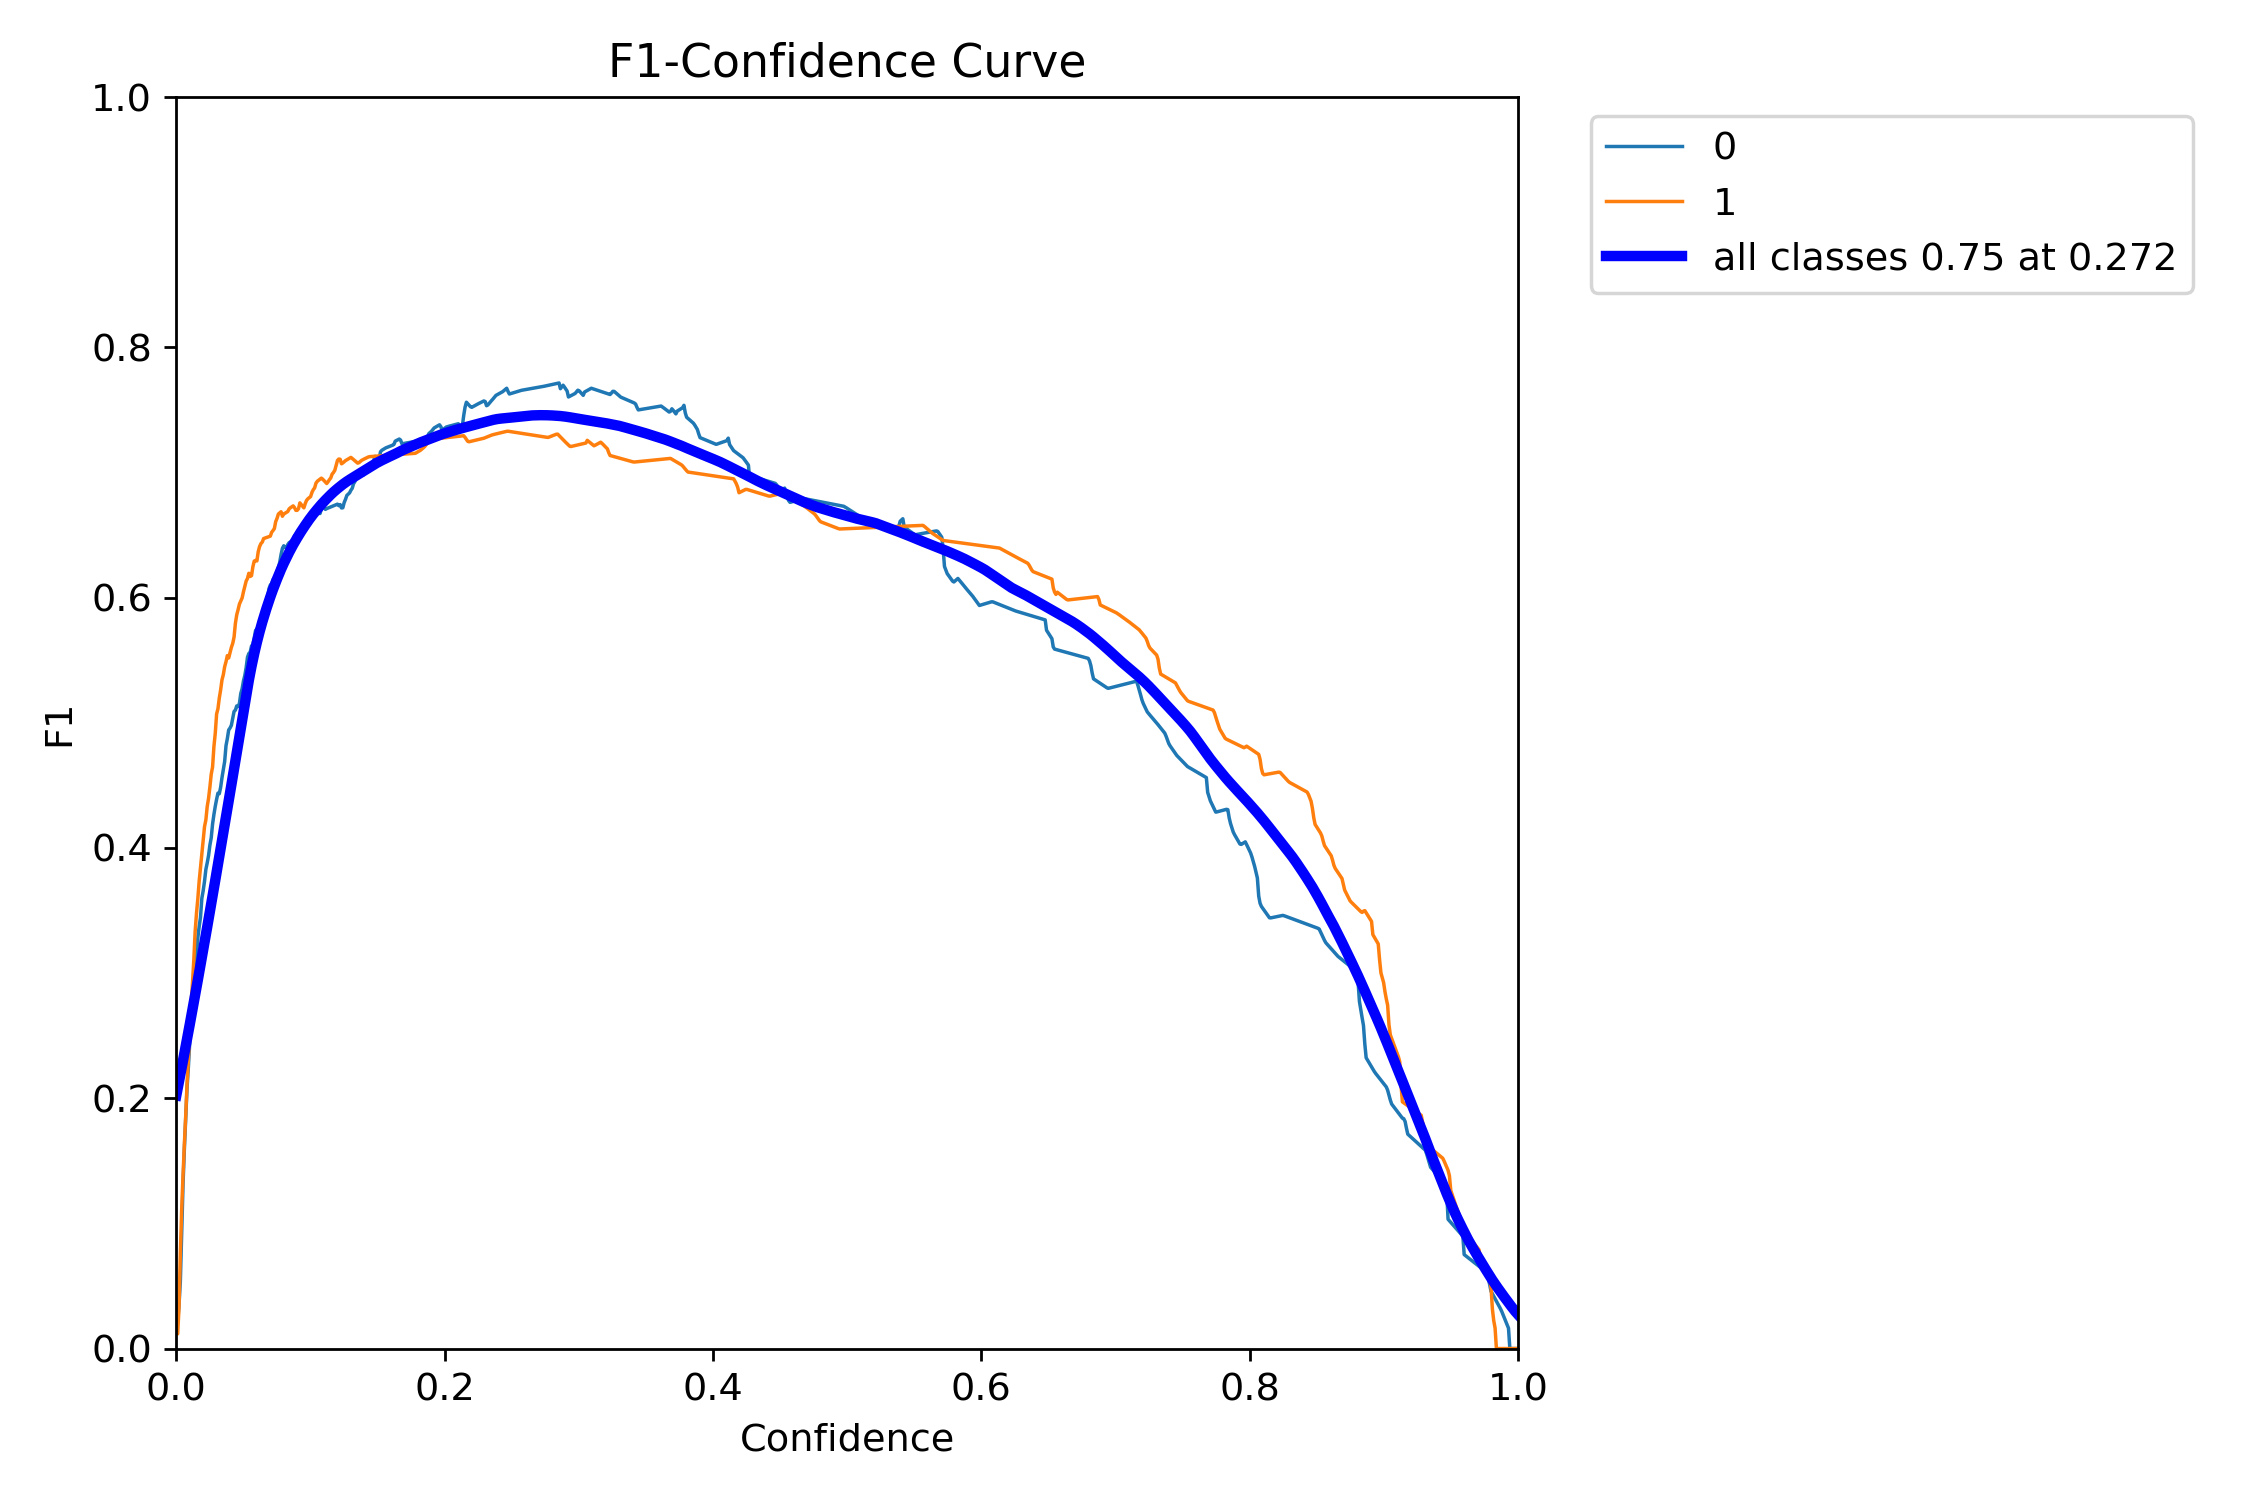

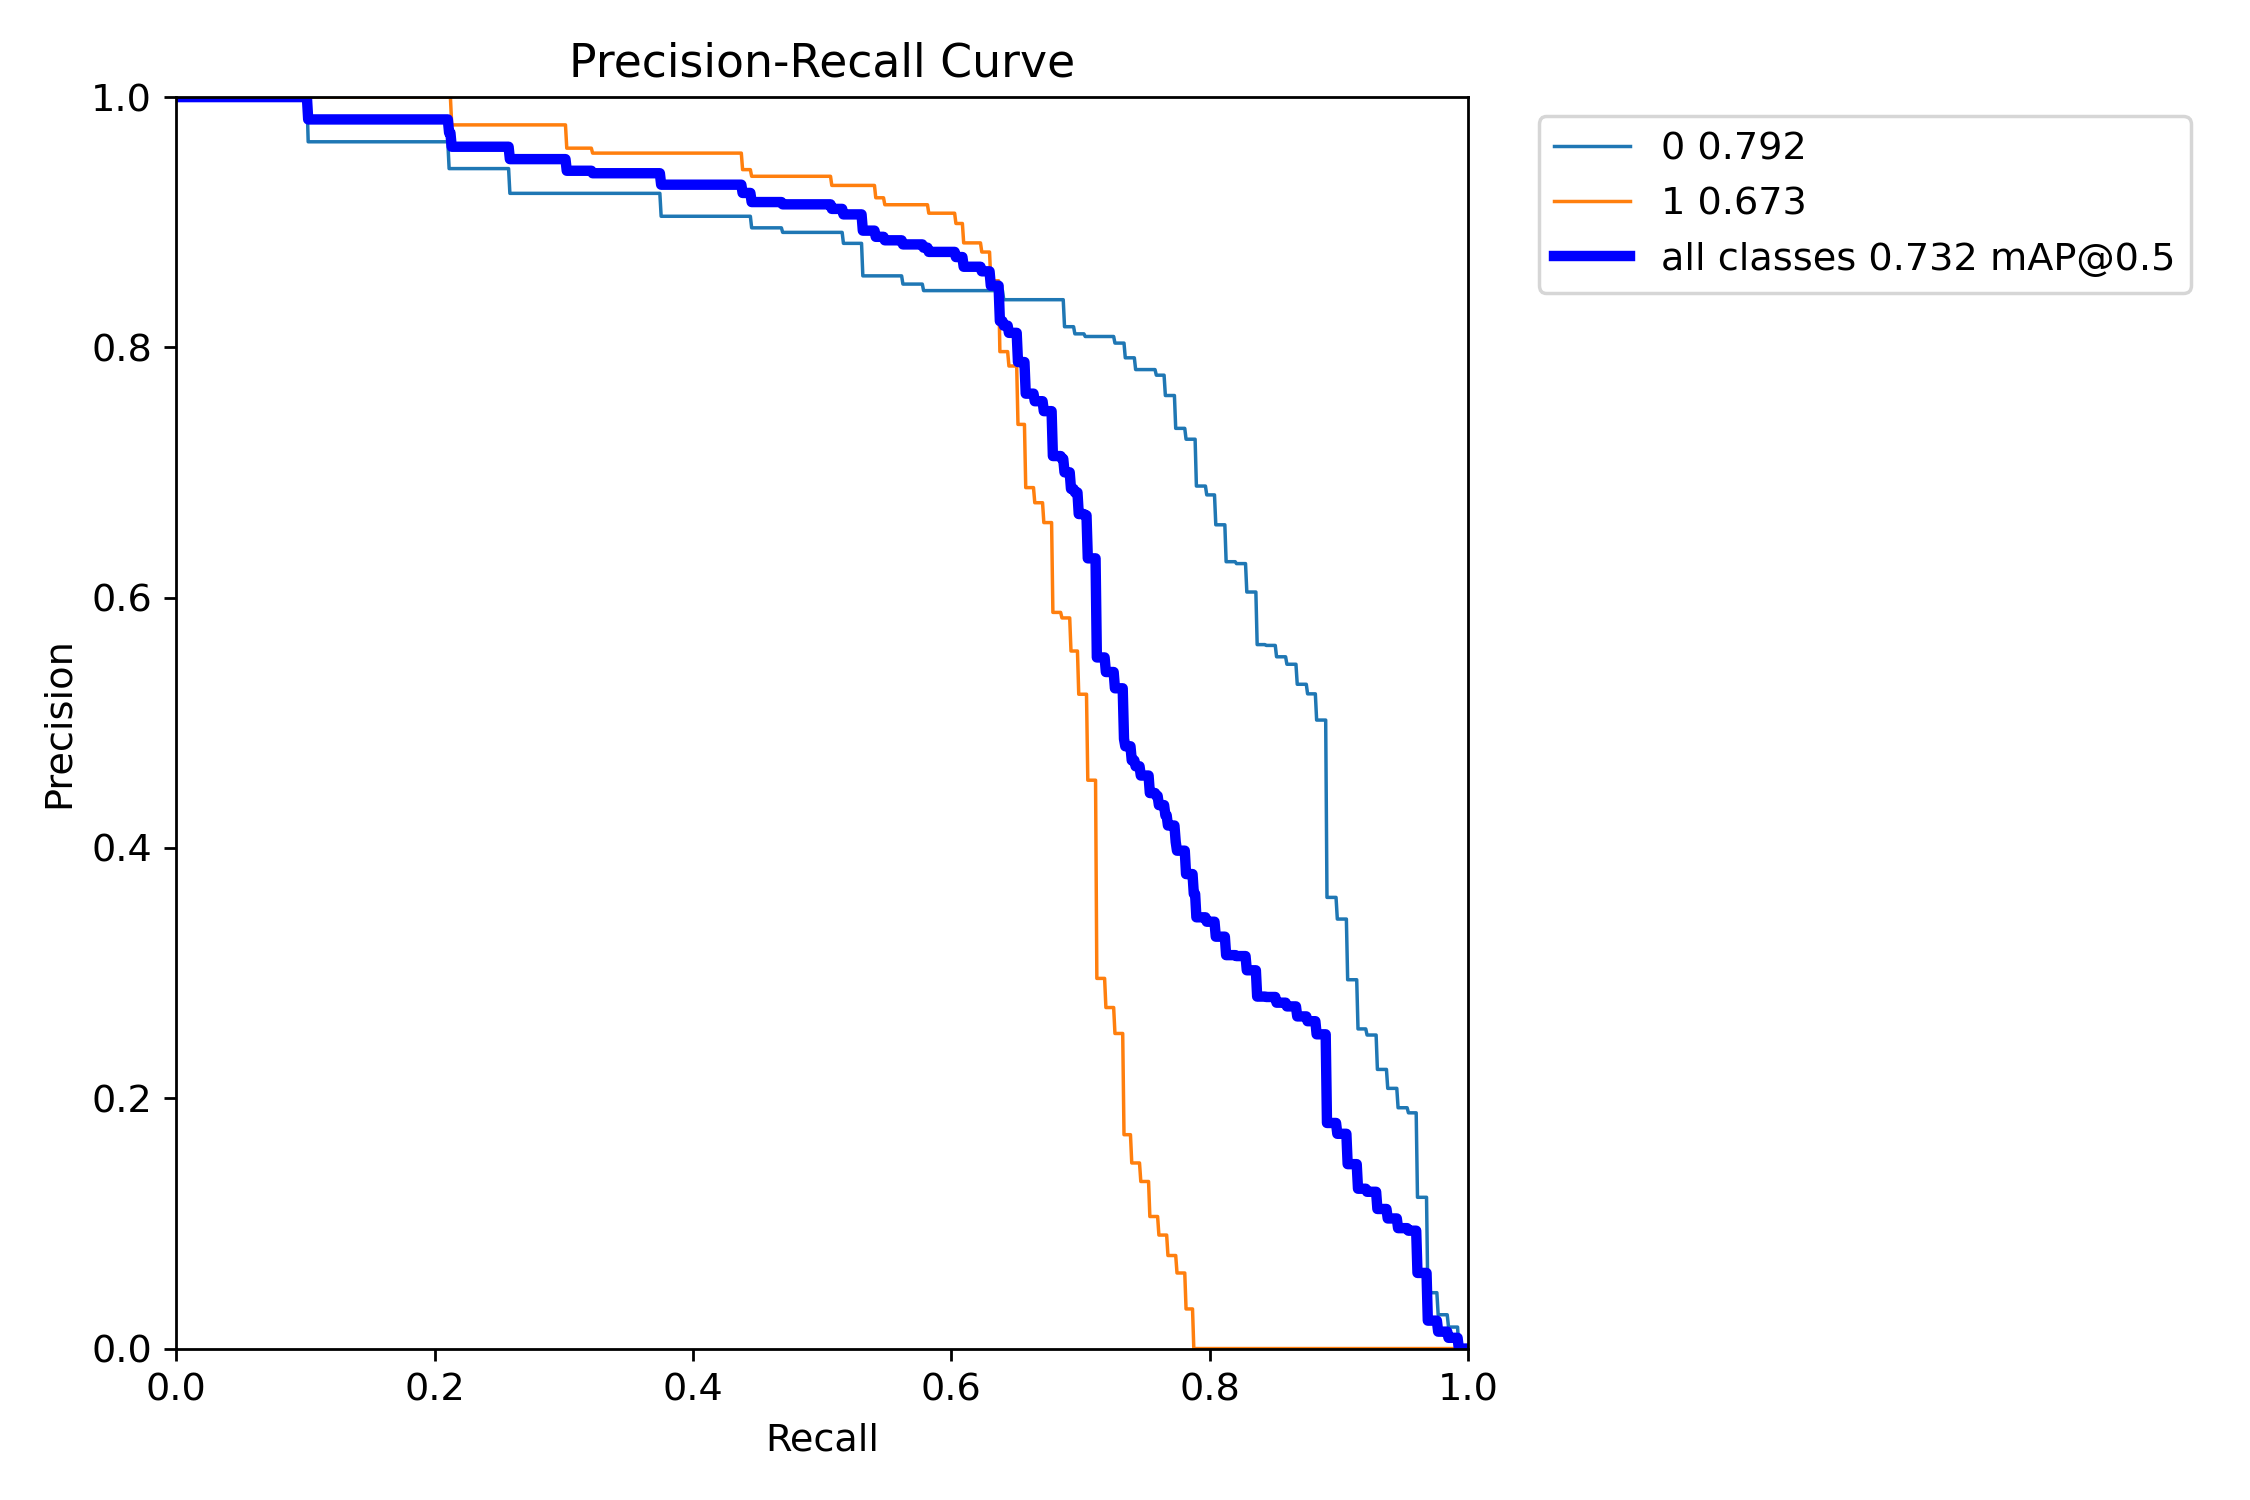

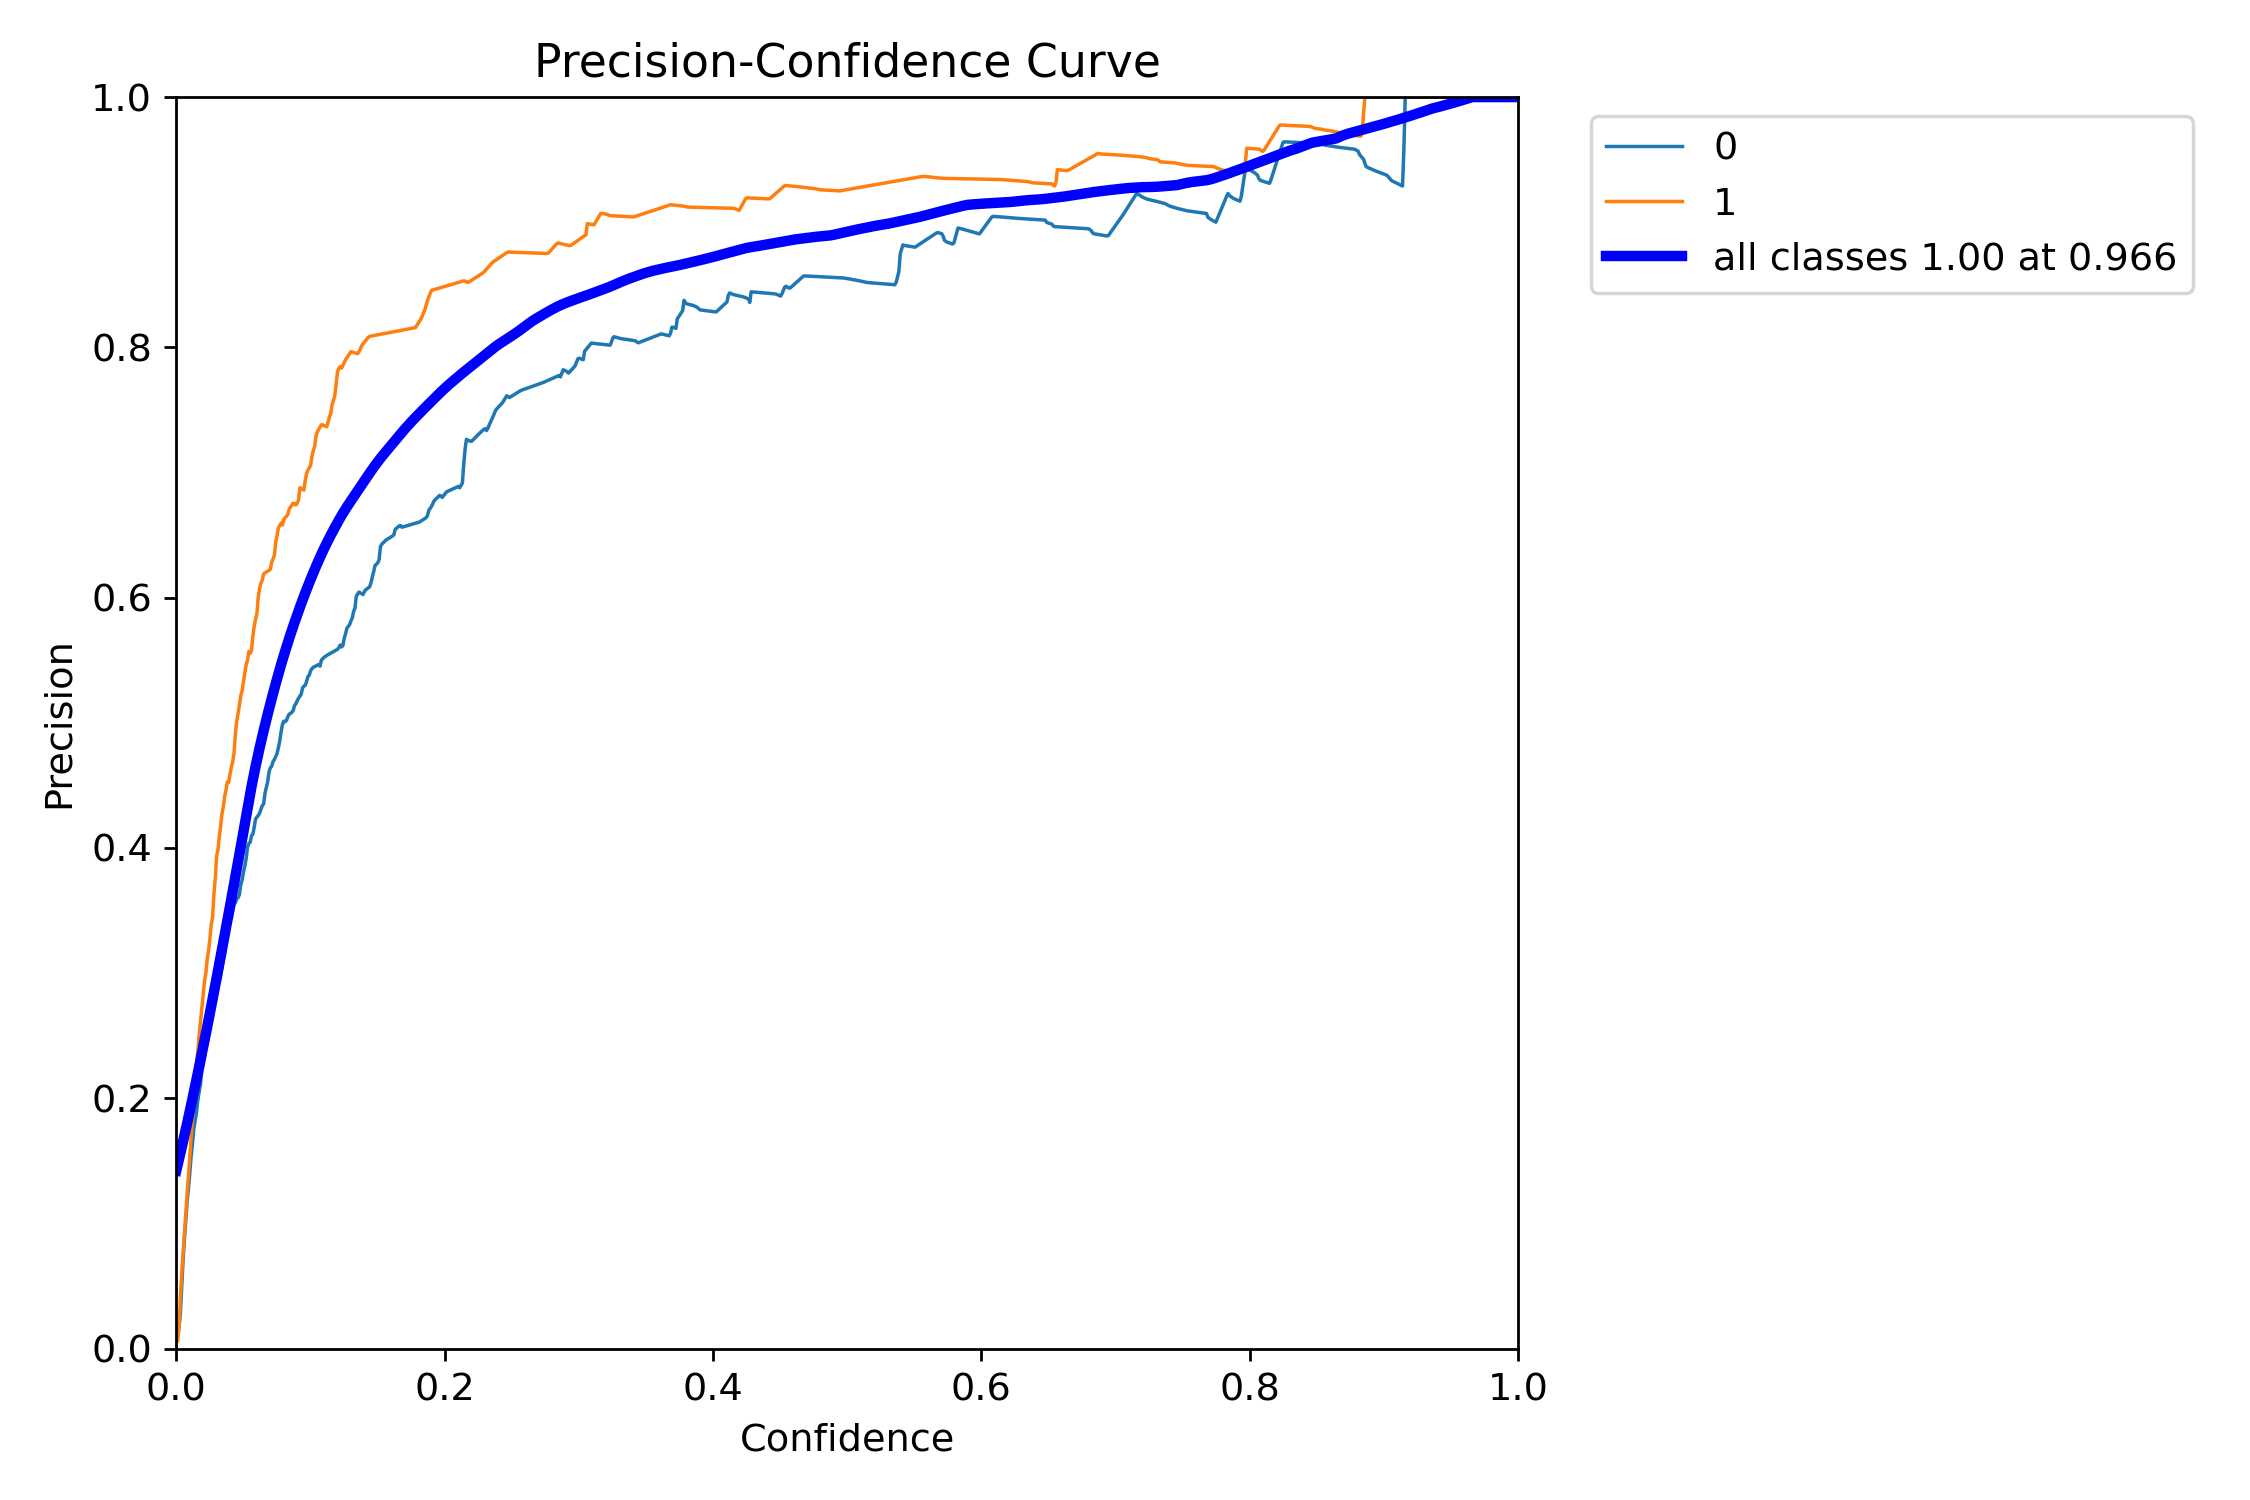

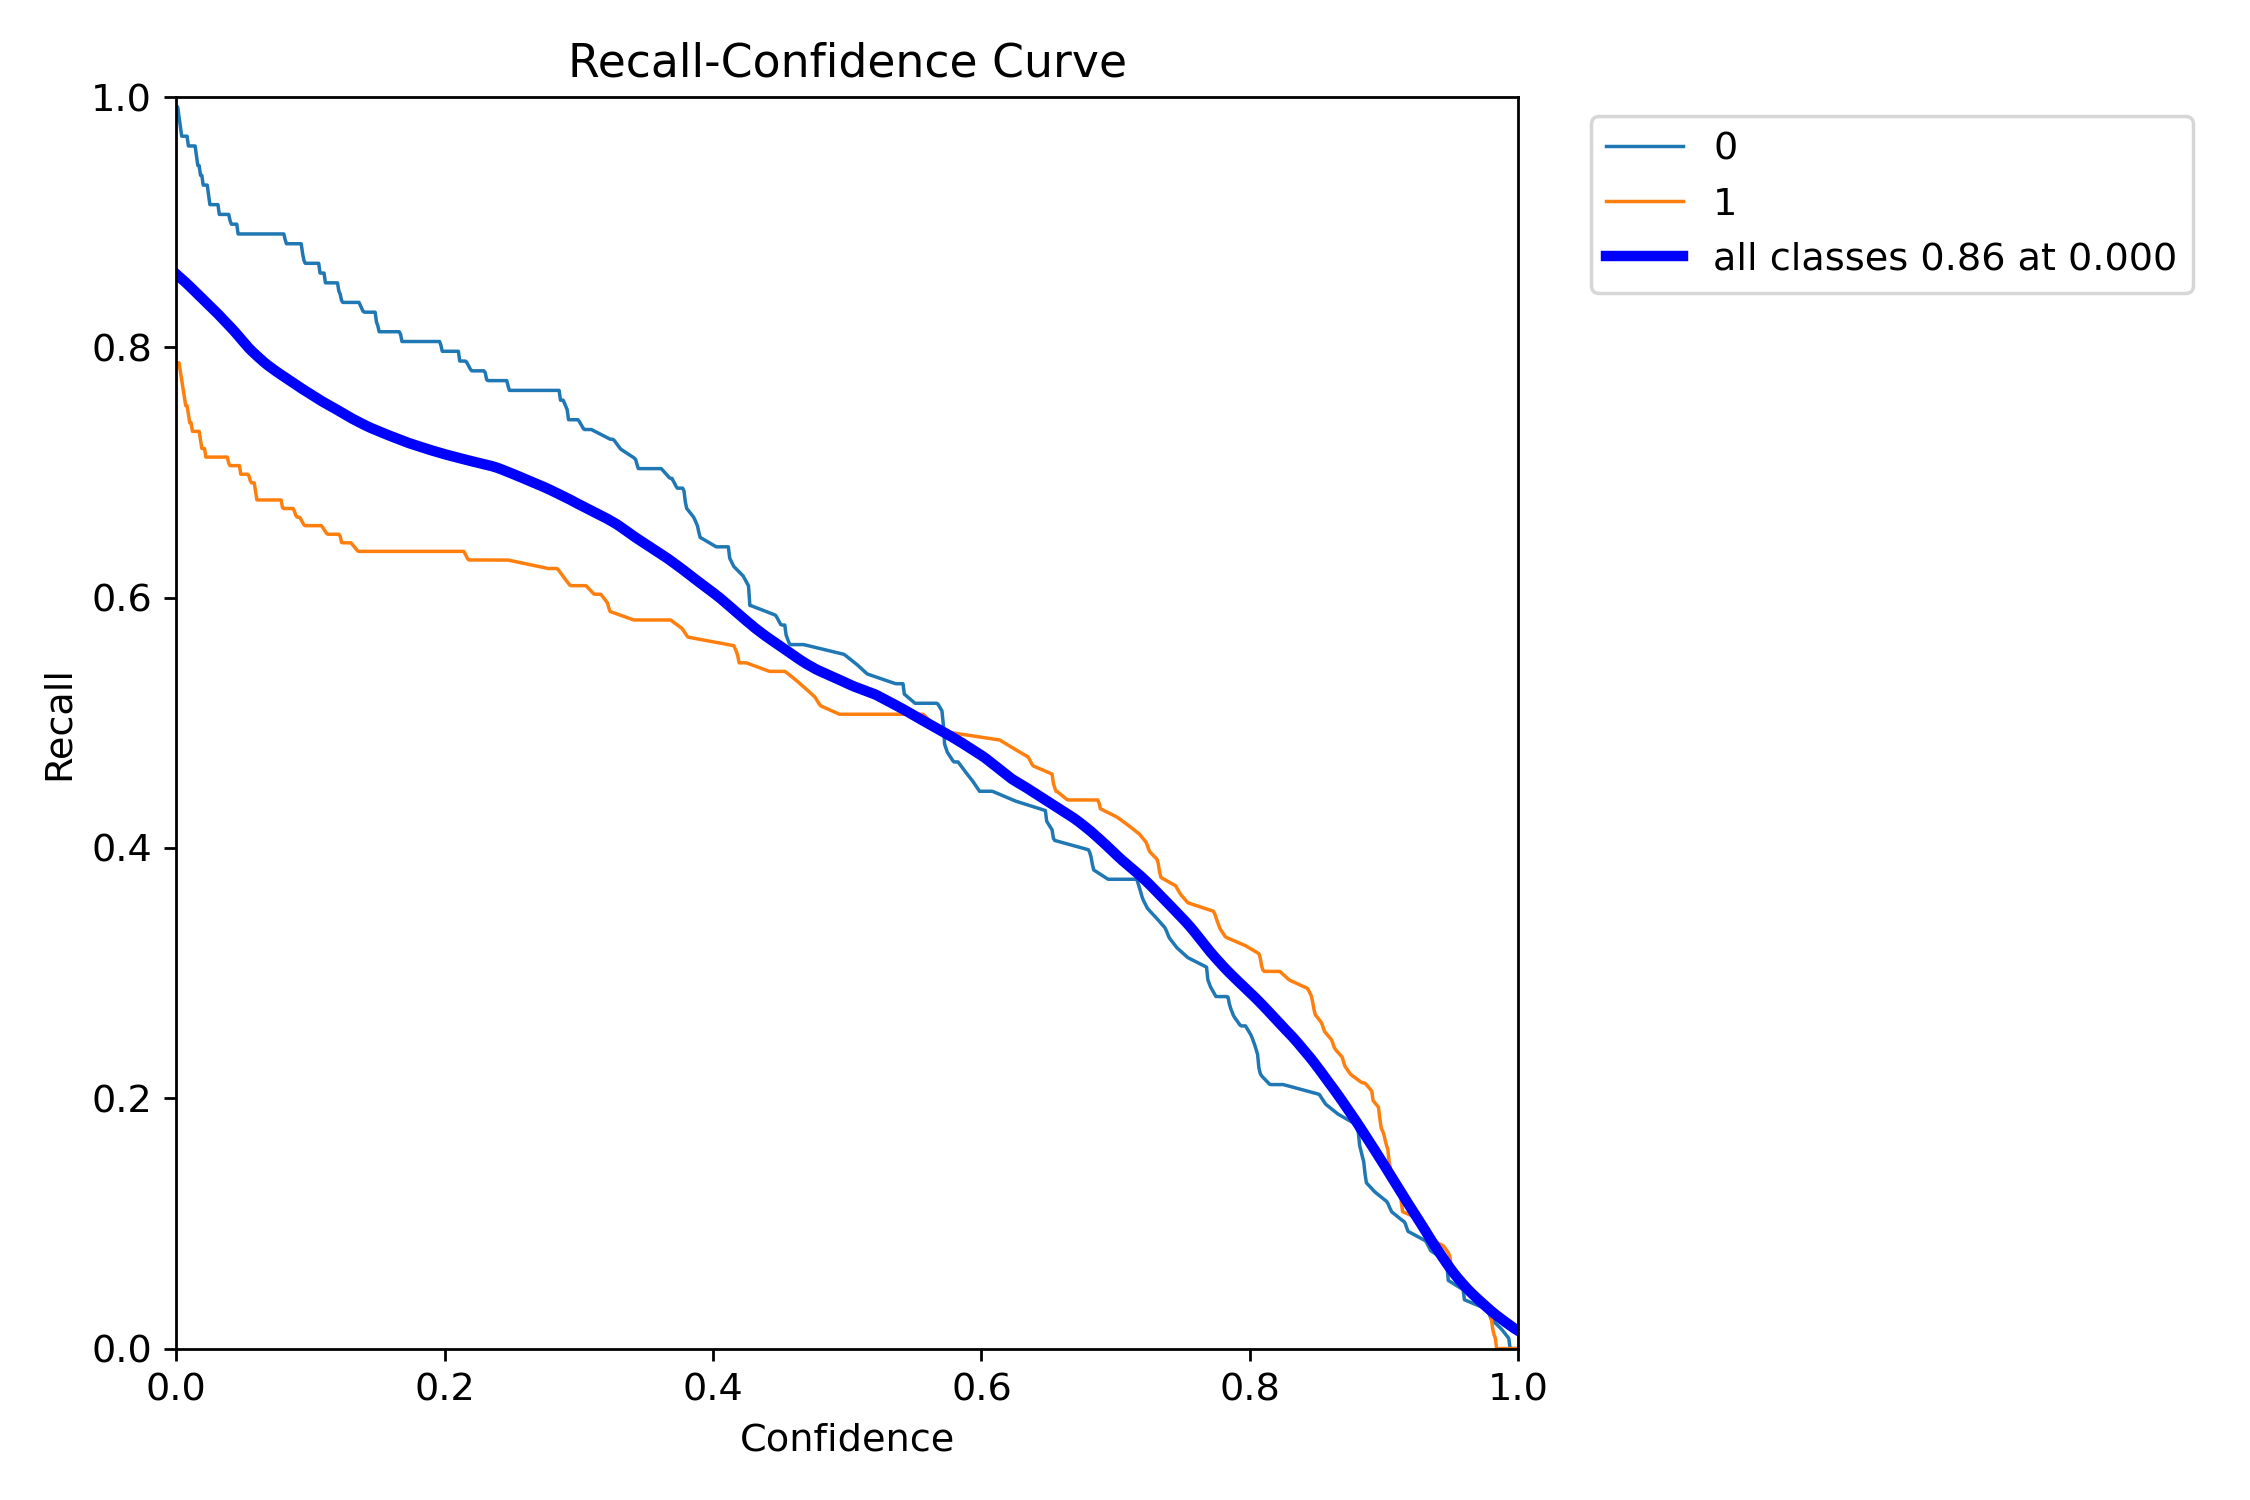

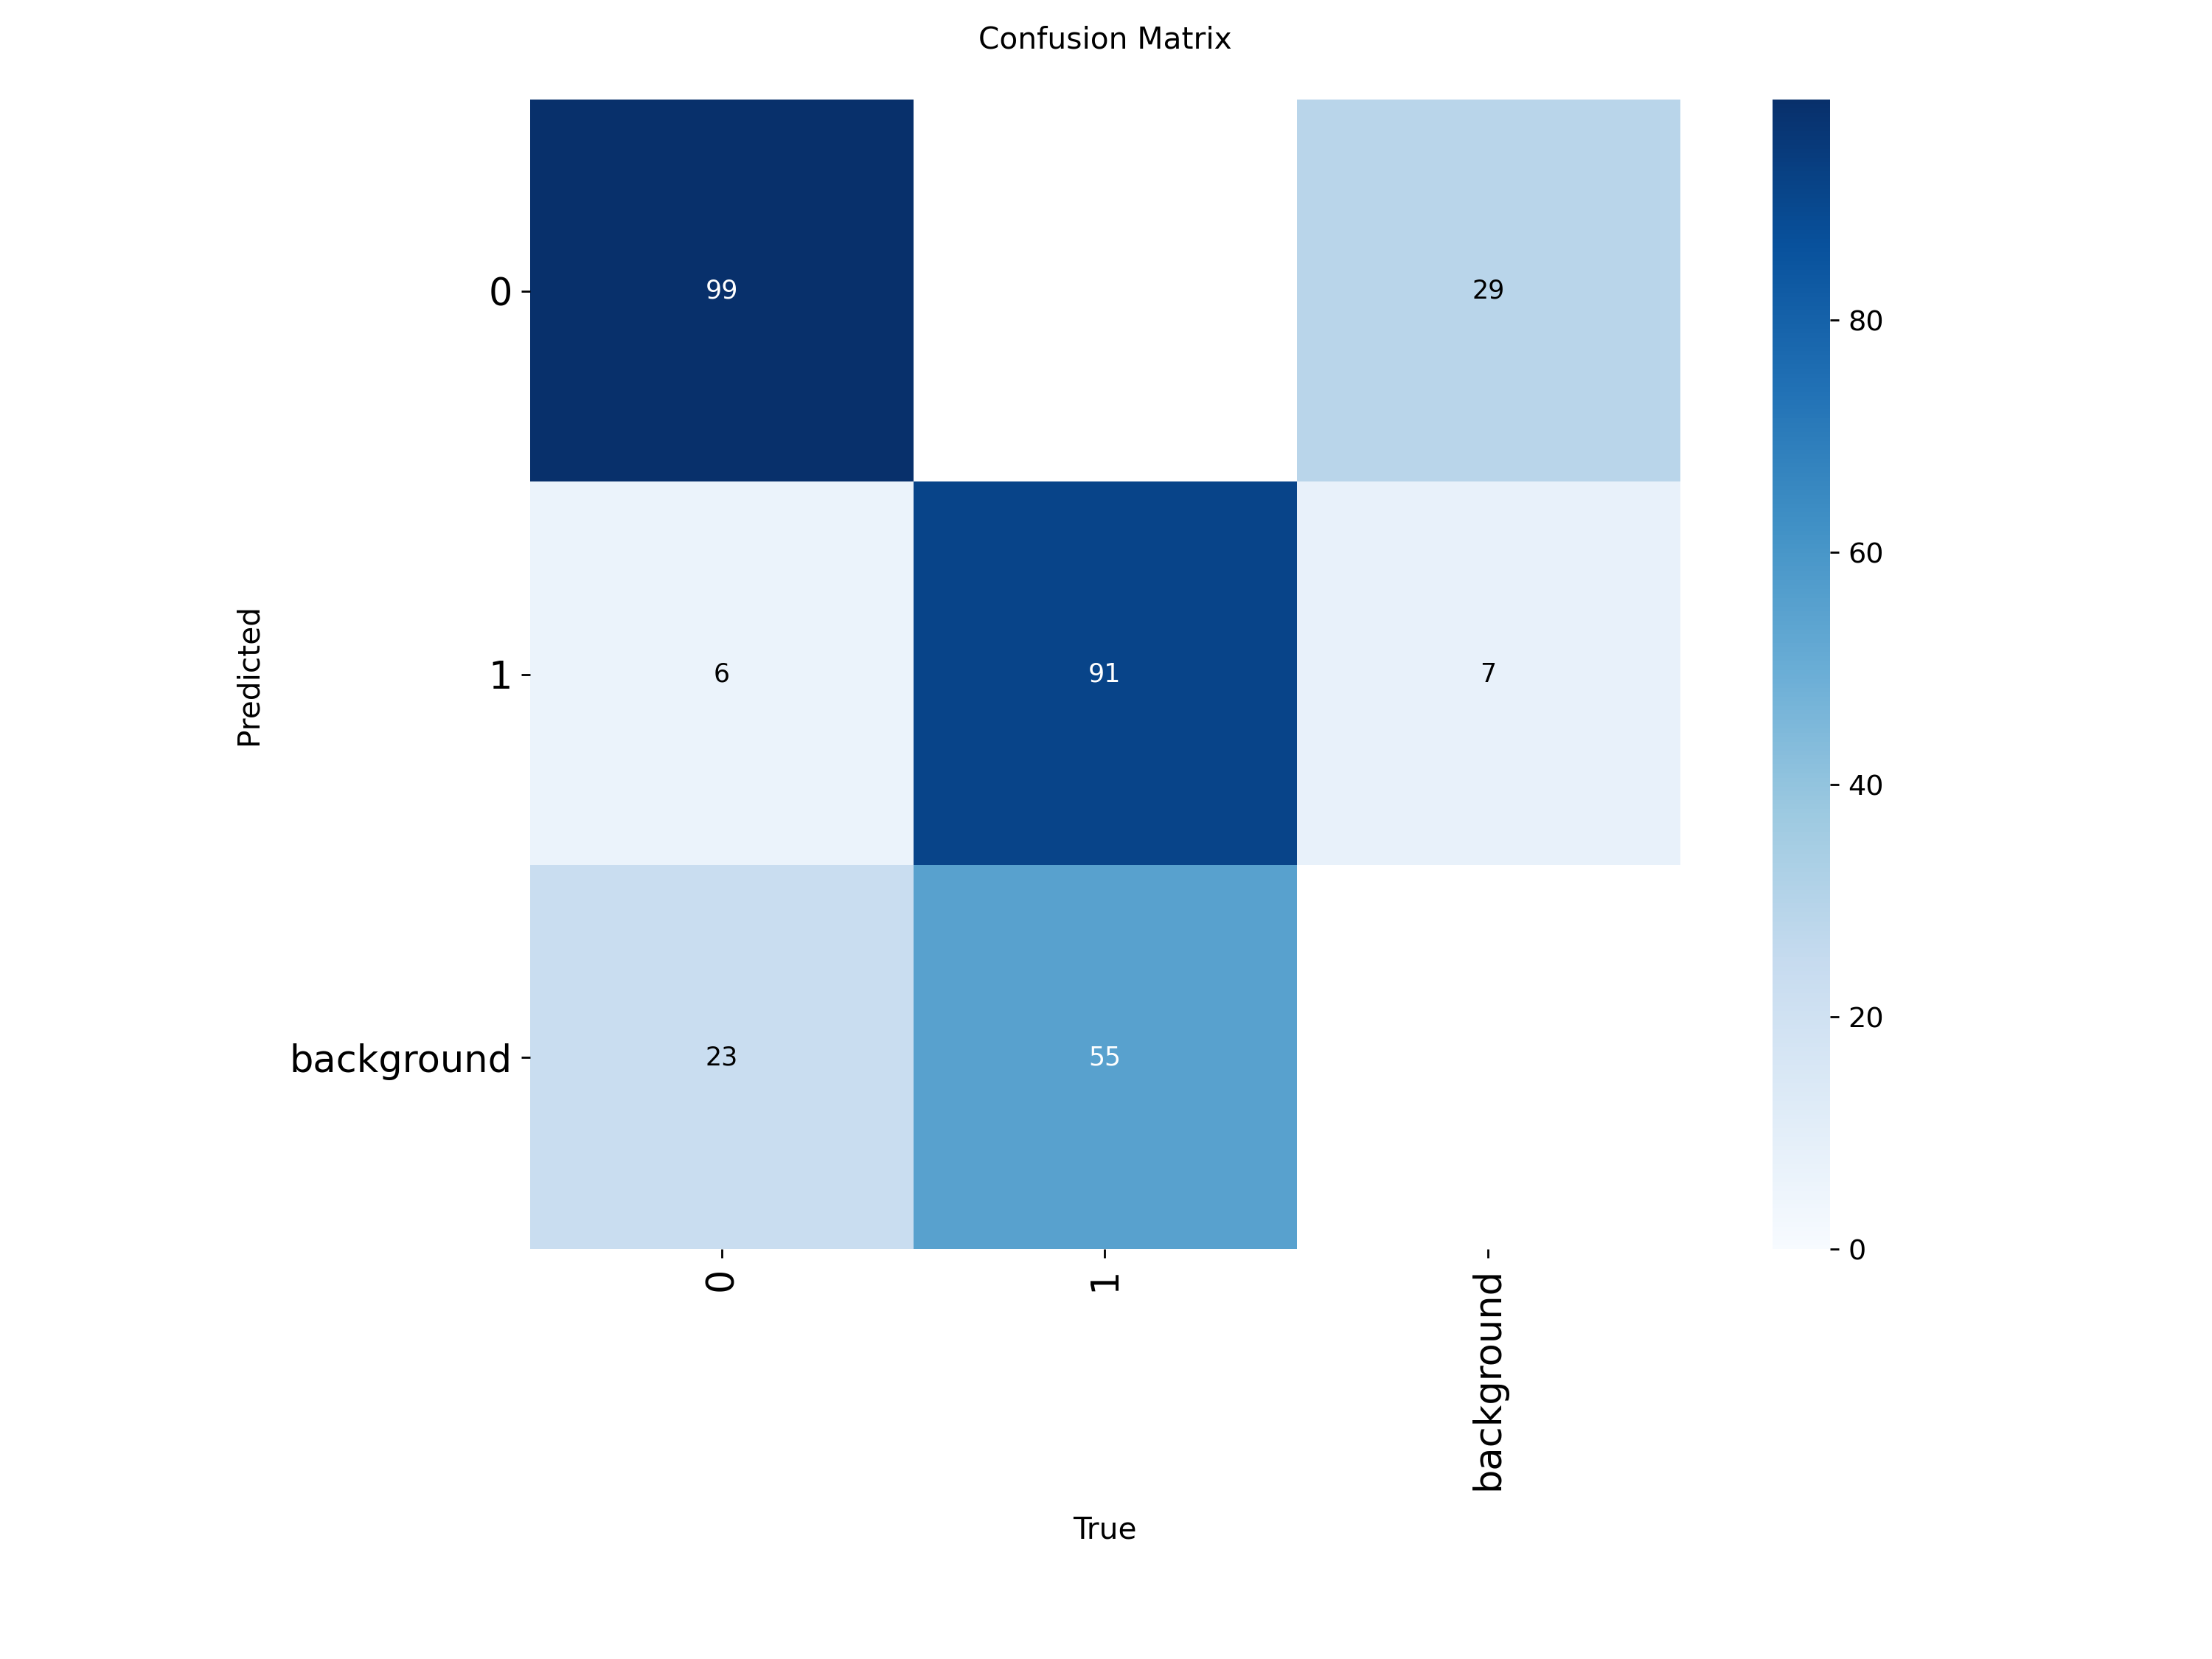

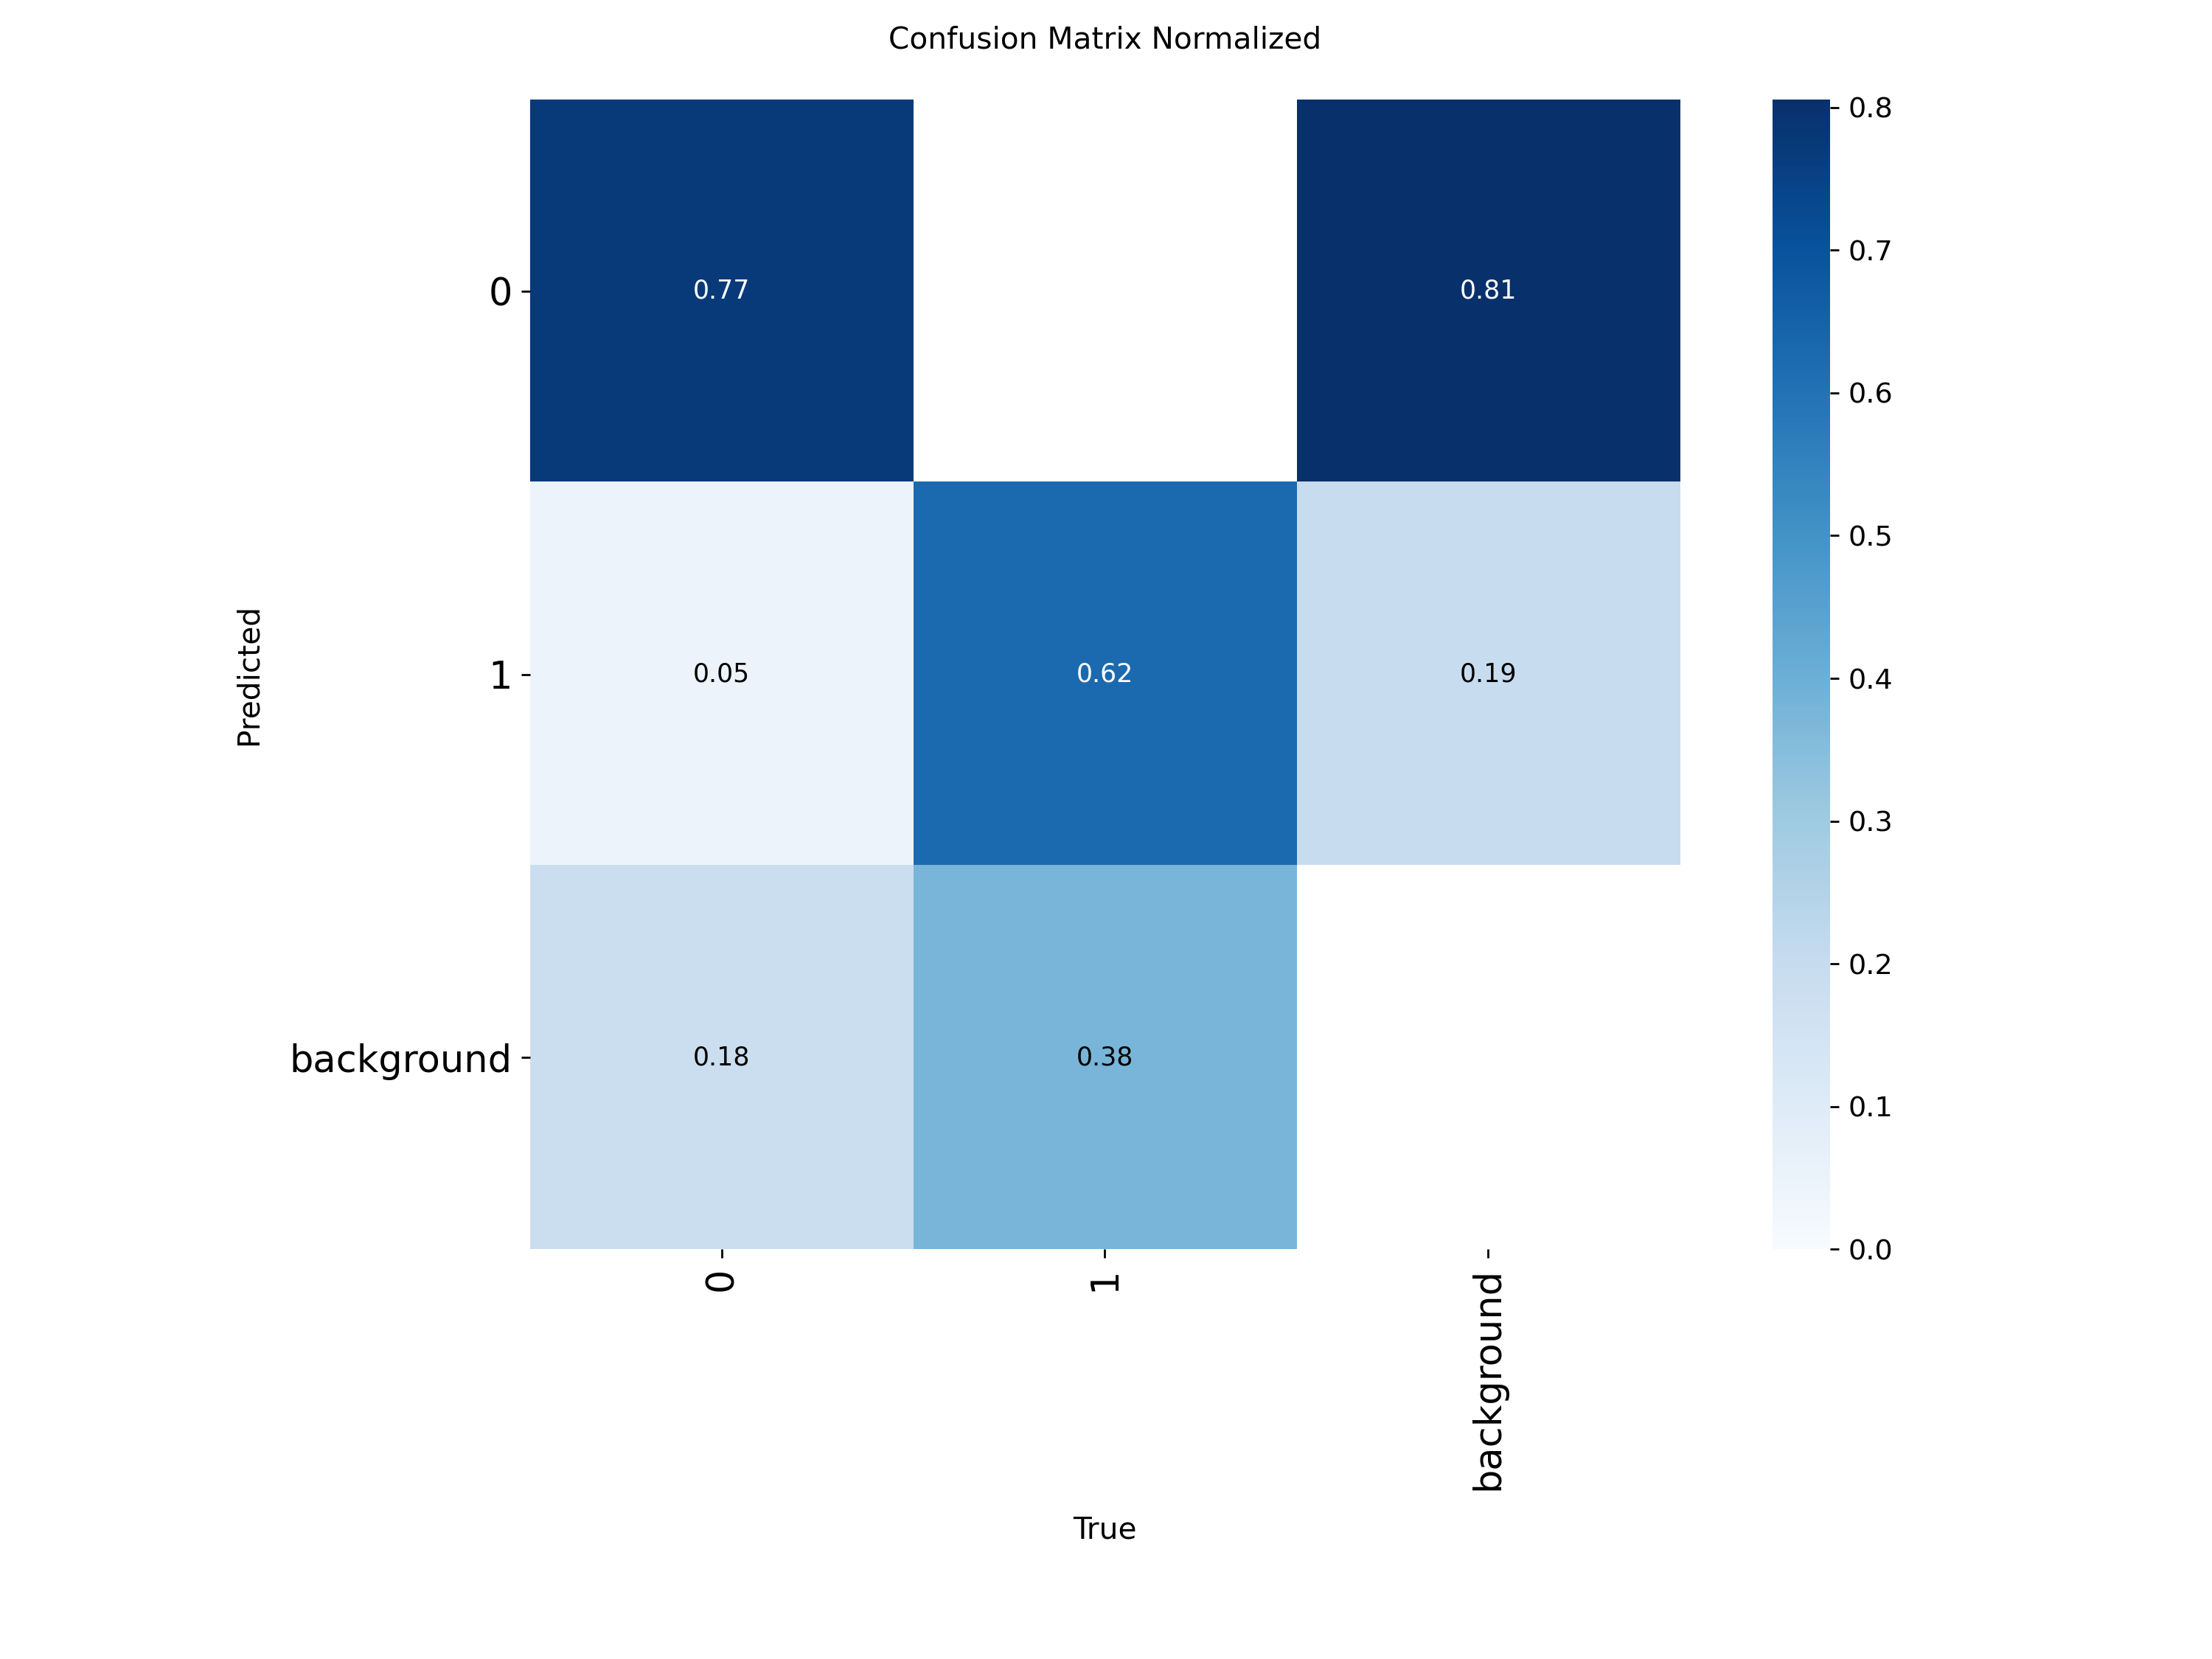

In [12]:
from PIL import Image
from IPython.display import display
import os

train_folder = "runs/detect"

latest_run = sorted(os.listdir(train_folder))[-1]
latest_path = os.path.join(train_folder, latest_run)

print("Training Results Folder:")
print(latest_path)

for file in os.listdir(latest_path):
    if file.endswith(".png"):
        display(Image.open(os.path.join(latest_path, file)))

In [9]:
metrics = model.val()

print(metrics)

Ultralytics 8.4.95  Python-3.13.7 torch-2.13.0+cpu CPU (Intel Core i5-5300U 2.30GHz)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
WARNING val: Slow image access detected (ping: 0.40.1 ms, read: 9.62.7 MB/s, size: 6.8 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning C:\Users\Localws\Helmet-Detection-1\valid\labels.cache... 126 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 126/126 8.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 3.4s/it 27.2s3.9ss
                   all        126        274      0.823      0.695      0.732      0.476
                     0         95        128      0.771      0.766      0.792      0.476
                     1         32        146      0.875      0.624      0.673      0.475
Speed: 3.0ms preprocess, 170.3ms inference, 0.0ms loss, 6.

In [13]:
from ultralytics import YOLO

best_model = YOLO("runs/detect/train/weights/best.pt")

In [14]:
import os

test_folder = os.path.join(dataset.location, "test", "images")

test_images = sorted(os.listdir(test_folder))

print("Total Test Images:", len(test_images))

Total Test Images: 156


In [15]:
for image in test_images[:10]:

    image_path = os.path.join(test_folder, image)

    best_model.predict(
        source=image_path,
        conf=0.25,
        save=True
    )

print("Inference completed successfully!")


image 1/1 C:\Users\Localws\Helmet-Detection-1\test\images\109_jpg.rf.afb5d712b9d469ac6e266fbd59c80f16.jpg: 320x224 1 0, 466.5ms
Speed: 6.5ms preprocess, 466.5ms inference, 20.3ms postprocess per image at shape (1, 3, 320, 224)
Results saved to C:\Users\Localws\runs\detect\predict

image 1/1 C:\Users\Localws\Helmet-Detection-1\test\images\11_jpg.rf.2e311f822818ef4167f098dd2c7481bb.jpg: 320x320 1 0, 570.1ms
Speed: 9.2ms preprocess, 570.1ms inference, 17.6ms postprocess per image at shape (1, 3, 320, 320)
Results saved to C:\Users\Localws\runs\detect\predict

image 1/1 C:\Users\Localws\Helmet-Detection-1\test\images\131_jpg.rf.b6d5e88ba4a79c8f65d5c8ac9d4b97cc.jpg: 320x320 2 0s, 361.4ms
Speed: 15.1ms preprocess, 361.4ms inference, 6.1ms postprocess per image at shape (1, 3, 320, 320)
Results saved to C:\Users\Localws\runs\detect\predict

image 1/1 C:\Users\Localws\Helmet-Detection-1\test\images\135_jpg.rf.a87e765a4dcd076263b4b74ee19bf3a7.jpg: 256x320 (no detections), 309.5ms
Speed: 5.7ms 

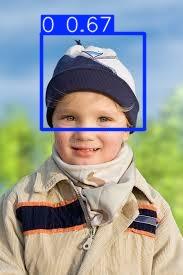

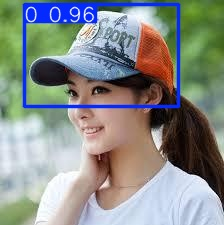

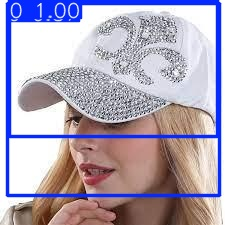

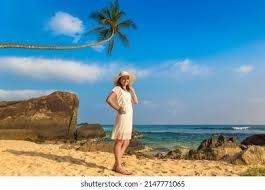

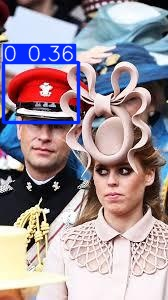

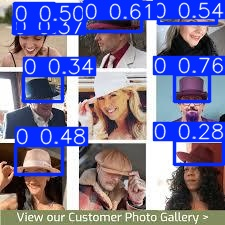

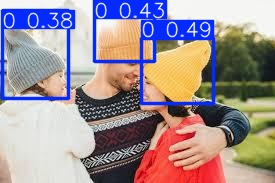

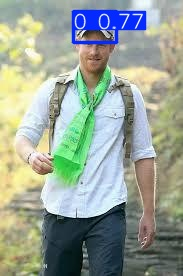

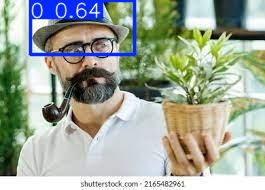

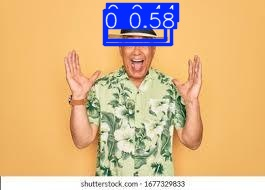

In [16]:
from PIL import Image
from IPython.display import display
import os

predict_folder = "runs/detect/predict"

output_images = sorted(os.listdir(predict_folder))

for img in output_images:
    display(Image.open(os.path.join(predict_folder, img)))

In [17]:
print(best_model.names)

{0: '0', 1: '1'}
